# EfficientViT-B1 — WaRP-C Waste Classification

El Mehdi Ziate


### What is EfficientViT?
EfficientViT is a hybrid CNN-Transformer model designed for efficiency. Like MobileViT, it combines local CNN features with global attention, but uses cascaded group attention with linear complexity instead of standard quadratic self-attention.

**Why EfficientViT for this experiment?**
This is a controlled ablation: EfficientViT and MobileViT share the same hybrid CNN so we want to confirm that models with a hybrid implementation can achieve a strong result on the warp dataset (which can give us a tradeoff of lowering the accuracy a bit but having a model with less parameters)

### Architecture — EfficientViT-B1
- 7.5M parameters (similar to MobileViT-Small at 5M)  
- Pretrained on ImageNet-1K  
- Cascaded group attention: each head sees different feature splits → diverse representations  
- Linear complexity attention → fast on GPU  

## Imports & Setup

In [7]:
import sys, time, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor, WARP_MEAN, WARP_STD
from Models.EfficientVit import EfficientViT_WaRP

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device  : cuda
PyTorch : 2.5.1+cu121


## Data Pipeline

Same setup as the optimised MobileViT notebook


In [8]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/WaRP-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 4,
    mean = [0.485, 0.456, 0.406],   
    std  = [0.229, 0.224, 0.225],
)

# pp.prepare(force=False)

train_loader, test_loader = pp.get_loaders(model_type='mobilevit')

class_weights = pp.get_class_weights(device=DEVICE)
criterion_p1  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
criterion_p2  = nn.CrossEntropyLoss(label_smoothing=0.1)
criterion     = criterion_p1

CLASS_NAMES = sorted(d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes       : {NUM_CLASSES}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Normalisation : mean={pp.mean}  std={pp.std}')

[get_loaders] model='mobilevit'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn_gentle'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49
Normalisation : mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


## EMA

In [ ]:
import copy

class ModelEMA:
    """
    Exponential Moving Average of model weights AND buffers.
    """
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.ema   = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        # Update parameters
        for ema_p, m_p in zip(self.ema.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(m_p.data, alpha=1 - self.decay)
        # Update buffers (BatchNorm running stats, etc.)
        for ema_b, m_b in zip(self.ema.buffers(), model.buffers()):
            ema_b.copy_(m_b.data)

    def evaluate(self, loader, device):
        self.ema.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in loader:
                preds    = self.ema(images.to(device)).argmax(1).cpu()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        return correct / total * 100

print('ModelEMA defined')


ModelEMA defined (with buffer sync fix)


## Training Configuration

Same hyperparameters as MobileViT for a fair comparison:
- Phase 1: 15 epochs, head only
- Phase 2: 45 epochs, full fine-tuning with differential LR
- Backbone LR = 8e-5 (10× lower than head, matching MobileViT)


In [11]:
HEAD_LR      = 1e-4      
BACKBONE_LR  = 1e-5      
WEIGHT_DECAY = 0.05      

NUM_EPOCHS    = 60
WARMUP_EPOCHS = 10

model = EfficientViT_WaRP(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)
ema   = ModelEMA(model, decay=0.999)

dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {out.shape}  ← should be (2, {NUM_CLASSES})')
print(f'Params : {model.count_all()}')

model.freeze_backbone()

optimizer    = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR, weight_decay=WEIGHT_DECAY,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS)
scaler       = GradScaler(enabled=(DEVICE == 'cuda'))

best_path = root / 'Models/weights/efficientvit_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)

print(f'Epochs    : {NUM_EPOCHS}  (Phase 1: 1-{WARMUP_EPOCHS}, Phase 2: {WARMUP_EPOCHS+1}-{NUM_EPOCHS})')
print(f'Head LR   : {HEAD_LR}   Backbone LR : {BACKBONE_LR}')
print(f'Pipeline  : pretrained_cnn_gentle (same as MobileViT — fair comparison)')

[EfficientViT_WaRP] Loaded pretrained efficientvit_b1
  Backbone features : 1600
  Head              : Linear(1600 → 28)
  Total parameters  : 7,545,852
Input  : torch.Size([2, 3, 224, 224])
Output : torch.Size([2, 28])  ← should be (2, 28)
Params : {'trainable': 7545852, 'frozen': 0, 'total': 7545852}
[EfficientViT_WaRP] Backbone FROZEN — training head only
Epochs    : 60  (Phase 1: 1-10, Phase 2: 11-60)
Head LR   : 0.0001   Backbone LR : 1e-05
Pipeline  : pretrained_cnn_gentle (same as MobileViT — fair comparison)


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_18084\1162458676.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler(enabled=(DEVICE == 'cuda'))


## Training Loop

In [12]:
def evaluate(m, loader, device):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds    = m(imgs.to(device)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total * 100


train_losses, train_accs, test_accs = [], [], []
best_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == WARMUP_EPOCHS + 1:
        model.unfreeze_backbone()
        print(f'\n→ Phase 2 started at epoch {epoch}')
        optimizer = torch.optim.AdamW(
            model.get_param_groups(head_lr=HEAD_LR, backbone_lr=BACKBONE_LR),
            weight_decay=WEIGHT_DECAY,
        )
        scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )
        criterion = criterion_p2
        print(f'  Loss → CrossEntropyLoss(label_smoothing=0.1)  [weights removed]')
        print(f'  Backbone LR={BACKBONE_LR}  Head LR={HEAD_LR}\n')

    model.train()
    epoch_loss = correct = total = 0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        epoch_loss += loss.item() * images.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    (scheduler_p1 if epoch <= WARMUP_EPOCHS else scheduler_p2).step()

    train_acc = correct / total * 100
    test_acc  = ema.evaluate(test_loader, DEVICE)
    avg_loss  = epoch_loss / total

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    flag = ''
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(ema.ema.state_dict(), best_path)
        flag = ' ← best'

    phase = 1 if epoch <= WARMUP_EPOCHS else 2
    lr    = optimizer.param_groups[-1]['lr']
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} [P{phase}] | loss={avg_loss:.4f} | '
          f'train={train_acc:.2f}% | test(EMA)={test_acc:.2f}% | '
          f'best={best_acc:.2f}% | lr={lr:.2e} | t={time.time()-t0:.1f}s{flag}')

print(f'\nBest test accuracy (EMA): {best_acc:.2f}%')
print(f'Weights saved → {best_path}')

C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_18084\2981052607.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch   1/60 [P1] | loss=2.9594 | train=5.54% | test(EMA)=2.58% | best=2.58% | lr=9.76e-05 | t=56.0s ← best
Epoch   2/60 [P1] | loss=2.6315 | train=7.99% | test(EMA)=3.48% | best=3.48% | lr=9.05e-05 | t=22.6s ← best
Epoch   3/60 [P1] | loss=2.4348 | train=12.12% | test(EMA)=3.74% | best=3.74% | lr=7.94e-05 | t=22.5s ← best
Epoch   4/60 [P1] | loss=2.3067 | train=16.91% | test(EMA)=4.84% | best=4.84% | lr=6.55e-05 | t=22.7s ← best
Epoch   5/60 [P1] | loss=2.1657 | train=20.27% | test(EMA)=6.51% | best=6.51% | lr=5.00e-05 | t=23.3s ← best
Epoch   6/60 [P1] | loss=2.1710 | train=22.85% | test(EMA)=8.19% | best=8.19% | lr=3.45e-05 | t=22.7s ← best
Epoch   7/60 [P1] | loss=2.0842 | train=25.00% | test(EMA)=8.77% | best=8.77% | lr=2.06e-05 | t=22.8s ← best
Epoch   8/60 [P1] | loss=2.0616 | train=25.85% | test(EMA)=11.28% | best=11.28% | lr=9.55e-06 | t=23.3s ← best
Epoch   9/60 [P1] | loss=2.0664 | train=26.10% | test(EMA)=11.86% | best=11.86% | lr=2.45e-06 | t=23.7s ← best
Epoch  10/60 [P1]

## Training Curves

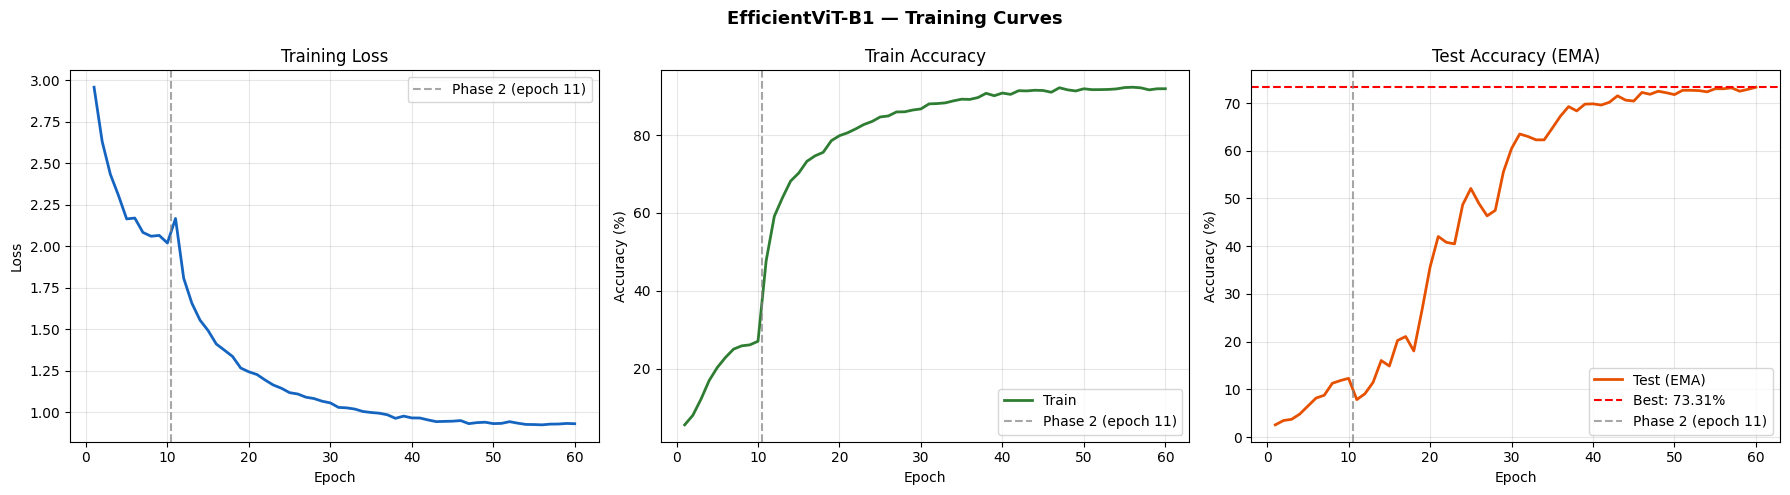

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EfficientViT-B1 — Training Curves', fontsize=13, fontweight='bold')

epochs     = range(1, NUM_EPOCHS + 1)
phase_line = dict(color='gray', linestyle='--', alpha=0.7, label=f'Phase 2 (epoch {WARMUP_EPOCHS+1})')

axes[0].plot(epochs, train_losses, '#1565C0', linewidth=2)
axes[0].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, '#2E7D32', linewidth=2, label='Train')
axes[1].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, test_accs, '#E65100', linewidth=2, label='Test (EMA)')
axes[2].axhline(best_acc, color='red', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[2].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[2].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (EMA)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/efficientvit_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation

In [14]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
top1_acc   = (all_preds == all_labels).mean() * 100

print(f'Test Top-1 Accuracy (EMA) : {top1_acc:.2f}%')
print(f'MobileViT-Small (5M)      : 74.60%')
print(f'ViT v1 (86M)              : 65.25%')
print(f'Swin v1 (28M)             : 62.99%')
print(f'Sayem et al. 2024 SOTA    : 83.11%')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

Test Top-1 Accuracy (EMA) : 73.31%
MobileViT-Small (5M)      : 74.60%
ViT v1 (86M)              : 65.25%
Swin v1 (28M)             : 62.99%
Sayem et al. 2024 SOTA    : 83.11%

                         precision    recall  f1-score   support

            bottle-blue      0.756     0.654     0.701       104
       bottle-blue-full      0.518     0.674     0.586        43
          bottle-blue5l      0.620     0.861     0.721        72
     bottle-blue5l-full      0.667     0.583     0.622        24
            bottle-dark      0.854     0.863     0.859        95
       bottle-dark-full      0.698     0.882     0.779        34
           bottle-green      0.829     0.919     0.872        74
      bottle-green-full      0.784     0.853     0.817        34
            bottle-milk      0.679     0.667     0.673        57
       bottle-milk-full      0.833     0.952     0.889        21
      bottle-multicolor      0.370     0.357     0.364        28
bottle-multicolorv-full      0.571     0.57

## 10 — Confusion Matrix

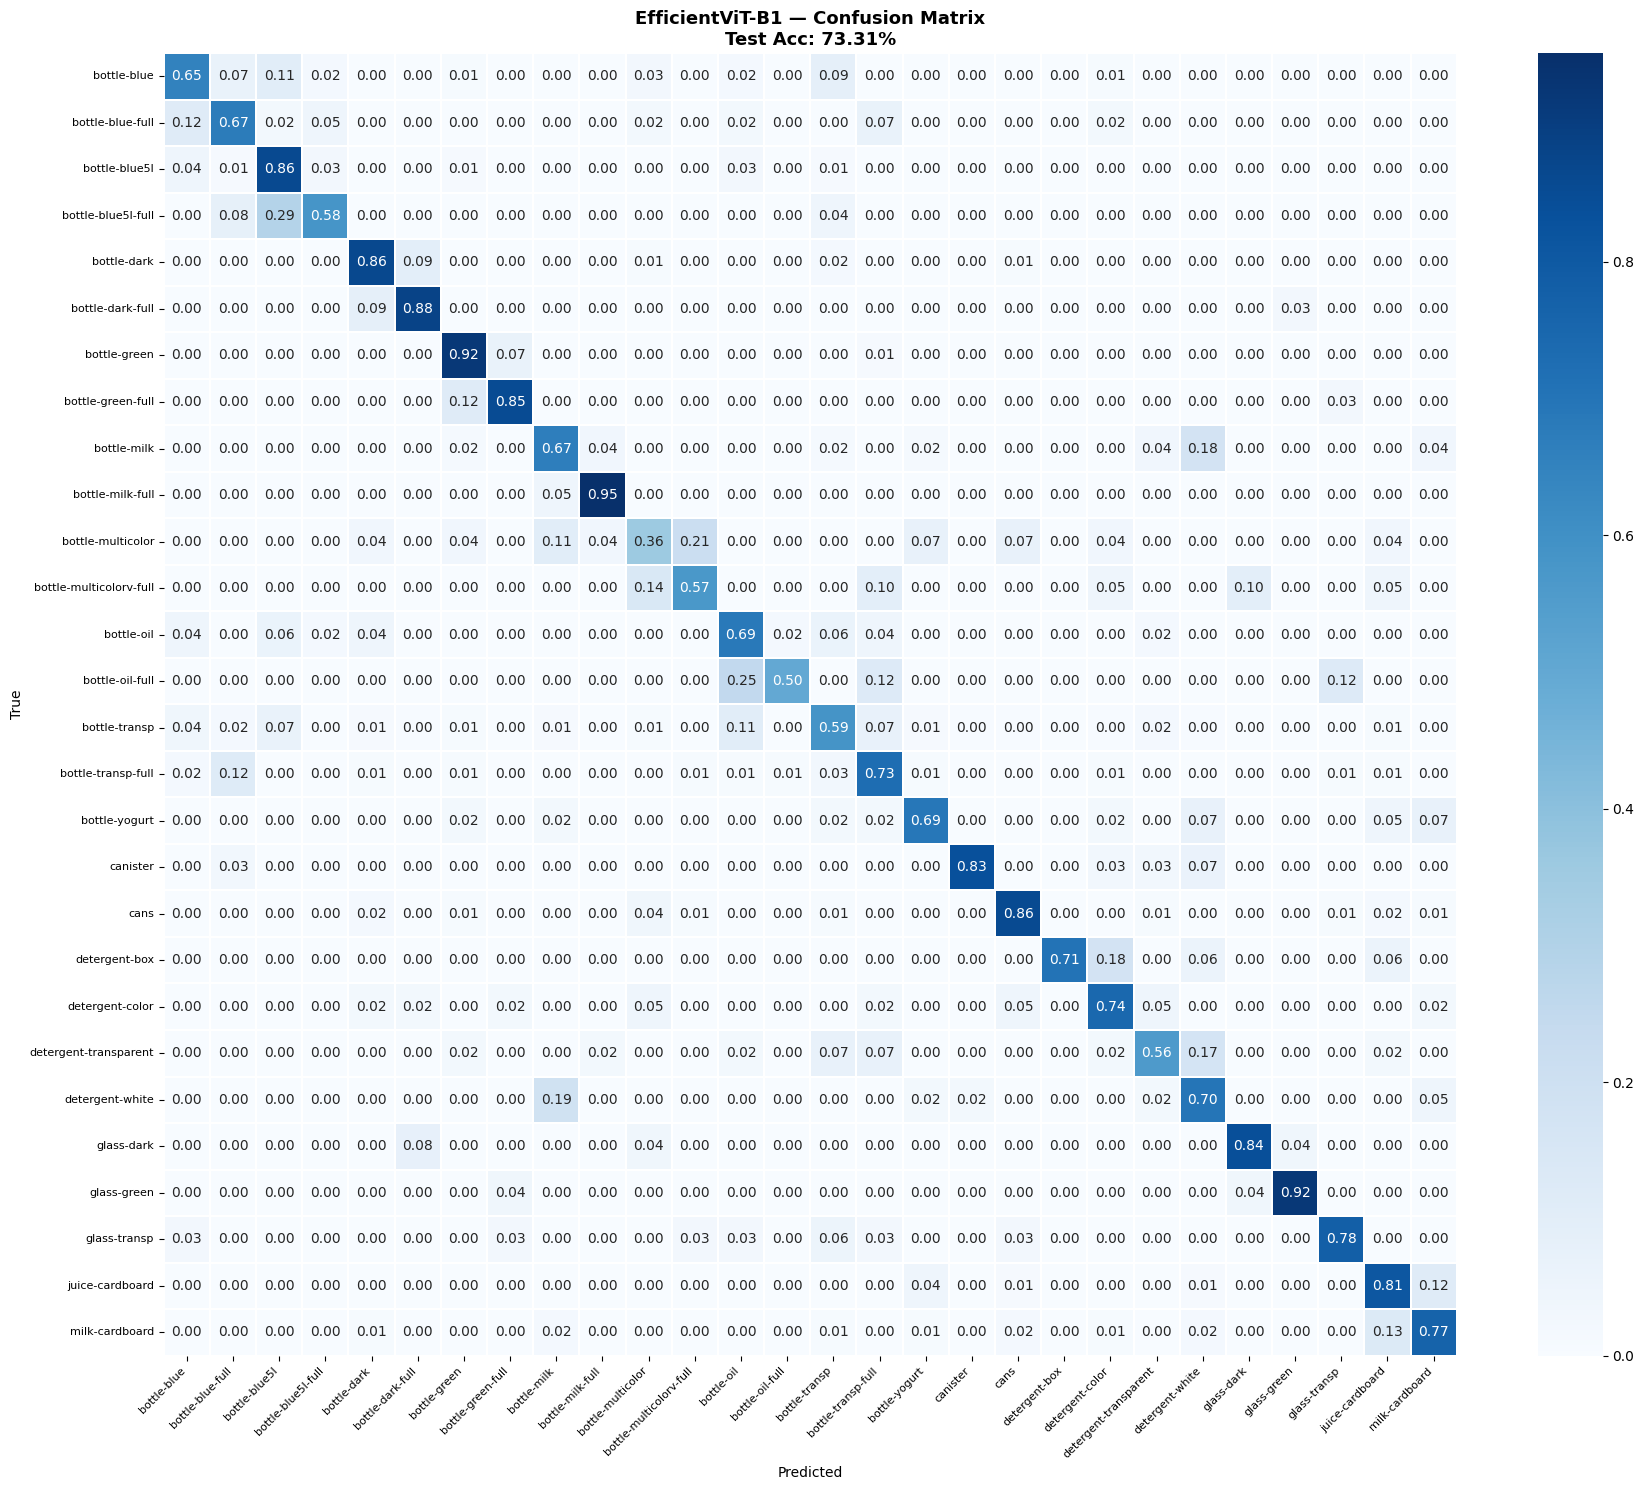

In [15]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_title(f'EfficientViT-B1 — Confusion Matrix\nTest Acc: {top1_acc:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(root / 'Dataset/figures/efficientvit_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [16]:
counts = model.count_all()
print('=' * 62)
print('  EfficientViT-B1 — Final Results')
print('=' * 62)
print(f'  Architecture  : EfficientViT-B1 (cascaded group attention)')
print(f'  Pretrained    : ImageNet-1K')
print(f'  Parameters    : {counts["total"]:,}')
print(f'  Epochs        : {NUM_EPOCHS} (Phase 1: {WARMUP_EPOCHS}, Phase 2: {NUM_EPOCHS-WARMUP_EPOCHS})')
print(f'  Best EMA acc  : {best_acc:.2f}%')
print(f'  Test accuracy : {top1_acc:.2f}%')
print()
print('  COMPARISON (same pipeline — pretrained_cnn_gentle + WaRP-C stats):')
print(f'  MobileViT-Small (5M)  : 74.60%')
print(f'  EfficientViT-B1 (~9M) : {top1_acc:.2f}%  ← this model')
print(f'  Swin-Tiny (28M) v1    : 62.99%')
print(f'  ViT-B/16 (86M) v1     : 65.25%')
print(f'  CNN baseline (~2M)    : 53.13%')
print(f'  SOTA 2S_DenseViT (51M): 83.11%')
print()
print('  Reference: Liu et al. (2023) EfficientViT CVPR')
print('=' * 62)

  EfficientViT-B1 — Final Results
  Architecture  : EfficientViT-B1 (cascaded group attention)
  Pretrained    : ImageNet-1K
  Parameters    : 7,545,852
  Epochs        : 60 (Phase 1: 10, Phase 2: 50)
  Best EMA acc  : 73.31%
  Test accuracy : 73.31%

  COMPARISON (same pipeline — pretrained_cnn_gentle + WaRP-C stats):
  MobileViT-Small (5M)  : 74.60%
  EfficientViT-B1 (~9M) : 73.31%  ← this model
  Swin-Tiny (28M) v1    : 62.99%
  ViT-B/16 (86M) v1     : 65.25%
  CNN baseline (~2M)    : 53.13%
  SOTA 2S_DenseViT (51M): 83.11%

  Reference: Liu et al. (2023) EfficientViT CVPR
